In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
'''骨架提取后的图片数据集载入，划分训练集测试集'''
import torch
import torchvision
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
transform1 = transforms.Compose([
    transforms.Resize([128, 128]),
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5,.5,.5],std=[.5,.5,.5])
])
transform2 = transforms.Compose([
    transforms.Resize([300, 300]),
    transforms.RandomCrop([128, 128]), #随机裁剪
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5,.5,.5],std=[.5,.5,.5])
])
transform3 = transforms.Compose([
    transforms.Resize([128, 128]),
    transforms.RandomAffine(20),  #随机仿射变化
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5,.5,.5],std=[.5,.5,.5])
])
transform4 = transforms.Compose([
    transforms.Resize([128, 128]),
    transforms.RandomEqualize(0.9),  #概率直方图均衡
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5,.5,.5],std=[.5,.5,.5])
])
transform5 = transforms.Compose([
    transforms.Resize([128, 128]),
    transforms.RandomHorizontalFlip(p=1),  #水平翻转
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5,.5,.5],std=[.5,.5,.5])
])
transform6 = transforms.Compose([
    transforms.Resize([128, 128]),
    transforms.ColorJitter(brightness=(0.5, 2)),  #亮度在0.5-2之间随机取值进行变化
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5,.5,.5],std=[.5,.5,.5])
])
transform7 = transforms.Compose([
    transforms.Resize([128, 128]),
    transforms.ColorJitter(contrast=(0.5, 2)),  #对比度在0.5-2之间随机取值进行变化
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5,.5,.5],std=[.5,.5,.5])
])
transform8 = transforms.Compose([
    transforms.Resize([128, 128]),
    transforms.ColorJitter(saturation=(0.5, 2)),  #饱和度在0.5-2之间随机取值进行变化
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5,.5,.5],std=[.5,.5,.5])
])
train_path ='/content/drive/MyDrive/yoga/annotated_image_evaluated_splited55/train/downdog'
test_path ='/content/drive/MyDrive/yoga/annotated_image_evaluated_splited55/test/downdog'
data1 = torchvision.datasets.ImageFolder(root=train_path,transform=transform1) 
data2 = torchvision.datasets.ImageFolder(root=train_path,transform=transform2)
data3 = torchvision.datasets.ImageFolder(root=train_path,transform=transform3)
data4 = torchvision.datasets.ImageFolder(root=train_path,transform=transform4)
data5 = torchvision.datasets.ImageFolder(root=train_path,transform=transform5)
data6 = torchvision.datasets.ImageFolder(root=train_path,transform=transform6)
data7 = torchvision.datasets.ImageFolder(root=train_path,transform=transform7)
data8 = torchvision.datasets.ImageFolder(root=train_path,transform=transform8)
trainset = data1+data2+data3+data4+data5+data6+data7+data8
testset = torchvision.datasets.ImageFolder(root=test_path,transform=transform1) 
print(data1.class_to_idx)
BATCH_SIZE = 4
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=BATCH_SIZE, shuffle=True)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=BATCH_SIZE, shuffle=False)

{'nonstandard': 0, 'standard': 1}


In [3]:
'''VGG19网络'''
import torchvision.models as models
import torch.nn as nn
vgg19 = models.vgg19(pretrained=True)
vgg19.classifier[6] = nn.Linear(in_features=4096, out_features=2, bias=True)
'''for i in range(1,4):
  vgg19.classifier[i] = nn.Sequential()'''
print(vgg19)

/usr/local/lib/python3.9/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.9/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


  0%|          | 0.00/548M [00:00<?, ?B/s]

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

In [4]:
'''定义训练和测试函数'''
import torch.optim as optim
from PIL import ImageFile
import matplotlib.pyplot as plt
def train_test(net, epoch_num, num_print):
    # 优化器
    criterion = nn.CrossEntropyLoss(reduction='sum')
    optimizer = optim.SGD(net.parameters(), lr = 0.0000004, momentum = 0.9)
    ImageFile.LOAD_TRUNCATED_IMAGES = True
    train_loss_list = []
    test_loss_list = []
    for epoch in range(epoch_num):
        running_loss = 0.0
        for i, data in enumerate(trainloader, 0):
            # 训练数据
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)
            # 权重参数清零
            optimizer.zero_grad()
            outputs = net(inputs)  # 正向传播
            loss = criterion(outputs, labels)
            loss.backward()  #  反向传播
            optimizer.step()
            running_loss += loss.item()
            if i %num_print == (num_print-1):
                print('[%d, %4d] loss:%.3f'%(epoch + 1, i+1, running_loss / num_print))
                train_loss_list.append(running_loss/num_print)
                running_loss = 0.0
        test_loss = 0.0
        with torch.no_grad():
            for data in testloader:
              images, labels = data
              images, labels = images.to(device), labels.to(device)
              outputs = net(images)
              #_,predicted = torch.max(outputs.data, 1)
              #print(predicted, labels)
              loss = criterion(outputs, labels)
              test_loss += loss.item()
            test_loss /= len(testloader.dataset)
            print('Test set: Average loss: {:.4f}'.format(test_loss))
            test_loss_list.append(test_loss)
    x_train_loss=[]
    x_test_loss=[]
    for i in range(len(train_loss_list)):
        x_train_loss.append(i+1)
    for i in range(len(test_loss_list)):
        x_test_loss.append(i+1)
    plt.plot(x_train_loss,train_loss_list)
    plt.ylabel("train loss")
    plt.show()
    plt.plot(x_test_loss,test_loss_list)
    plt.ylabel("test loss")
    plt.show()
    print('Finished Training')
    torch.save(net, '/content/drive/MyDrive/yoga/models/downdog/YogaEvaNet_downdog1_split.pkl')
    df_trainloss = pd.DataFrame()
    df_trainloss['trainloss'] = train_loss_list
    df_trainloss.to_csv('/content/drive/MyDrive/yoga/loss/downdog/trainloss1_split.csv',index=False)
    df_testloss = pd.DataFrame()
    df_testloss['testloss'] = test_loss_list
    df_testloss.to_csv('/content/drive/MyDrive/yoga/loss/downdog/testloss1_split.csv',index=False)
import pandas as pd
def test(net):
    correct = 0
    total = 0
    total_l = [0,0]
    correct_l = [0,0]
    pred_y = torch.tensor([]).to(device)
    Y_test = torch.tensor([]).to(device)
    with torch.no_grad():
        for data in testloader:
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            outputs = net(images)
            _,predicted = torch.max(outputs.data, 1)
            pred_y = torch.cat([pred_y,predicted])
            Y_test = torch.cat([Y_test,labels])
            total += labels.size(0)
            correct += (predicted == labels).sum().item() 
            for i in range(len(labels)):
                for l in range(2):
                    if labels[i] == torch.tensor(l).to(device):
                        total_l[l] += 1
                        correct_l[l] += (predicted[i] == labels[i]).sum().item()
    print('测试集精度为：%d%%'%(100 * correct / total))
    print('测试集中不标准动作图片的预测精度为：%d%%'%(100 * correct_l[0] / total_l[0]))
    print('测试集中标准动作图片的预测精度为：%d%%'%(100 * correct_l[1] / total_l[1]))
    print('混淆矩阵为：')
    print(pd.crosstab(Y_test.cpu(), pred_y.cpu()))

In [5]:
import torch.optim as optim
from PIL import ImageFile
import matplotlib.pyplot as plt
import pandas as pd
def train_test2(net, epoch_num, num_print):
    # 优化器
    criterion = nn.CrossEntropyLoss(reduction='sum')
    optimizer = optim.SGD(net.parameters(), lr = 0.0000004, momentum = 0.9)
    ImageFile.LOAD_TRUNCATED_IMAGES = True
    df_trainloss = pd.read_csv('/content/drive/MyDrive/yoga/loss/downdog/trainloss1_split.csv')
    train_loss_list = df_trainloss['trainloss'].tolist()
    df_testloss = pd.read_csv('/content/drive/MyDrive/yoga/loss/downdog/testloss1_split.csv')
    test_loss_list = df_testloss['testloss'].tolist()
    for epoch in range(epoch_num):
        running_loss = 0.0
        for i, data in enumerate(trainloader, 0):
            # 训练数据
            inputs1, labels = data
            inputs1, labels = inputs1.to(device), labels.to(device)
            # 权重参数清零
            optimizer.zero_grad()
            outputs = net(inputs1)  # 正向传播
            loss = criterion(outputs, labels)
            loss.backward()  #  反向传播
            optimizer.step()
            running_loss += loss.item()
            if i %num_print == (num_print-1):
                print('[%d, %4d] loss:%.3f'%(epoch + 1, i+1, running_loss / num_print))
                train_loss_list.append(running_loss/num_print)
                running_loss = 0.0
        test_loss = 0.0
        with torch.no_grad():
            for data in testloader:
              images1, labels = data
              images1, labels = images1.to(device), labels.to(device)
              outputs = net(images1)
              #_,predicted = torch.max(outputs.data, 1)
              #print(predicted, labels)
              loss = criterion(outputs, labels)
              test_loss += loss.item()
            test_loss /= len(testloader.dataset)
            print('Test set: Average loss: {:.4f}'.format(test_loss))
            test_loss_list.append(test_loss)
    x_train_loss=[]
    x_test_loss=[]
    for i in range(len(train_loss_list)):
        x_train_loss.append(i+1)
    for i in range(len(test_loss_list)):
        x_test_loss.append(i+1)
    plt.plot(x_train_loss,train_loss_list)
    plt.ylabel("train loss")
    plt.show()
    plt.plot(x_test_loss,test_loss_list)
    plt.ylabel("test loss")
    plt.show()
    print('Finished Training')
    torch.save(net, '/content/drive/MyDrive/yoga/models/downdog/YogaEvaNet_downdog1_split.pkl')
    df_trainloss = pd.DataFrame()
    df_trainloss['trainloss'] = train_loss_list
    df_trainloss.to_csv('/content/drive/MyDrive/yoga/loss/downdog/trainloss1_split.csv',index=False)
    df_testloss = pd.DataFrame()
    df_testloss['testloss'] = test_loss_list
    df_testloss.to_csv('/content/drive/MyDrive/yoga/loss/downdog/testloss1_split.csv',index=False)

In [ ]:
device = torch.device( 'cuda' if torch.cuda.is_available() else 'cpu')
test(vgg19.to(device))

测试集精度为：46%
测试集中不标准动作图片的预测精度为：64%
测试集中标准动作图片的预测精度为：31%
混淆矩阵为：
col_0  0.0  1.0
row_0          
0.0     34   19
1.0     45   21


[1,   50] loss:3.013
[1,  100] loss:3.184
[1,  150] loss:3.283
[1,  200] loss:3.310
Test set: Average loss: 0.7323
[2,   50] loss:3.125
[2,  100] loss:3.069
[2,  150] loss:3.054
[2,  200] loss:3.201
Test set: Average loss: 0.7562
[3,   50] loss:2.856
[3,  100] loss:2.984
[3,  150] loss:2.913
[3,  200] loss:2.796
Test set: Average loss: 0.7032
[4,   50] loss:2.791
[4,  100] loss:2.597
[4,  150] loss:2.839
[4,  200] loss:3.004
Test set: Average loss: 0.6333
[5,   50] loss:2.831
[5,  100] loss:2.822
[5,  150] loss:2.958
[5,  200] loss:2.764
Test set: Average loss: 0.7139
[6,   50] loss:2.707
[6,  100] loss:2.635
[6,  150] loss:2.722
[6,  200] loss:2.742
Test set: Average loss: 0.6933
[7,   50] loss:2.653
[7,  100] loss:2.620
[7,  150] loss:2.568
[7,  200] loss:2.759
Test set: Average loss: 0.6740
[8,   50] loss:2.549
[8,  100] loss:2.501
[8,  150] loss:2.658
[8,  200] loss:2.540
Test set: Average loss: 0.6822
[9,   50] loss:2.574
[9,  100] loss:2.586
[9,  150] loss:2.724
[9,  200] loss:2.

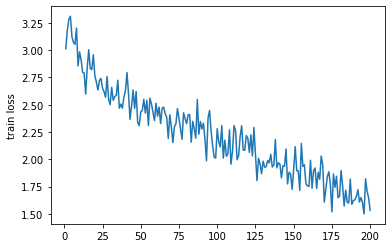

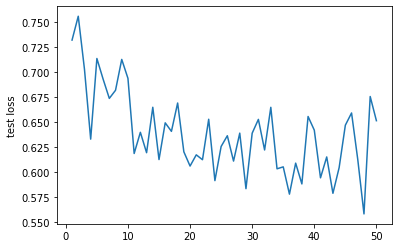

Finished Training


In [ ]:
import os
from torch import nn
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
device = torch.device( 'cuda' if torch.cuda.is_available() else 'cpu')
train_test(vgg19.to(device),50,50)

[1,   50] loss:1.369
[1,  100] loss:1.871
[1,  150] loss:1.656
[1,  200] loss:1.736
Test set: Average loss: 0.5944
[2,   50] loss:1.685
[2,  100] loss:1.538
[2,  150] loss:1.661
[2,  200] loss:1.771
Test set: Average loss: 0.6115
[3,   50] loss:1.596
[3,  100] loss:1.616
[3,  150] loss:1.855
[3,  200] loss:1.711
Test set: Average loss: 0.6282
[4,   50] loss:1.676
[4,  100] loss:1.510
[4,  150] loss:1.499
[4,  200] loss:1.614
Test set: Average loss: 0.6770
[5,   50] loss:1.684
[5,  100] loss:1.644
[5,  150] loss:1.674
[5,  200] loss:1.700
Test set: Average loss: 0.6448
[6,   50] loss:1.607
[6,  100] loss:1.448
[6,  150] loss:1.740
[6,  200] loss:1.701
Test set: Average loss: 0.6751
[7,   50] loss:1.454
[7,  100] loss:1.414
[7,  150] loss:1.479
[7,  200] loss:1.539
Test set: Average loss: 0.6437
[8,   50] loss:1.273
[8,  100] loss:1.629
[8,  150] loss:1.686
[8,  200] loss:1.422
Test set: Average loss: 0.6693
[9,   50] loss:1.514
[9,  100] loss:1.531
[9,  150] loss:1.598
[9,  200] loss:1.

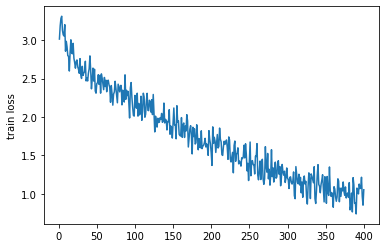

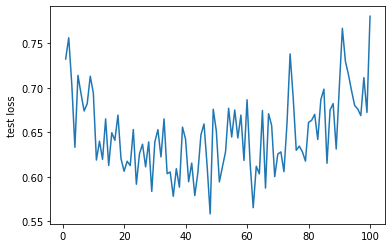

Finished Training


In [ ]:
import os
from torch import nn
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
device = torch.device( 'cuda' if torch.cuda.is_available() else 'cpu')
model = torch.load('/content/drive/MyDrive/yoga/models/downdog/YogaEvaNet_downdog1_split.pkl')
train_test2(model.to(device),50,50)

[1,   50] loss:1.042
[1,  100] loss:0.857
[1,  150] loss:1.099
[1,  200] loss:0.796
Test set: Average loss: 0.8194
[2,   50] loss:0.995
[2,  100] loss:0.975
[2,  150] loss:0.987
[2,  200] loss:0.876
Test set: Average loss: 0.6503
[3,   50] loss:0.941
[3,  100] loss:1.074
[3,  150] loss:0.810
[3,  200] loss:0.923
Test set: Average loss: 0.7604
[4,   50] loss:1.181
[4,  100] loss:0.960
[4,  150] loss:0.831
[4,  200] loss:0.900
Test set: Average loss: 0.7278
[5,   50] loss:0.865
[5,  100] loss:0.935
[5,  150] loss:1.052
[5,  200] loss:0.924
Test set: Average loss: 0.6818
[6,   50] loss:0.885
[6,  100] loss:0.933
[6,  150] loss:0.911
[6,  200] loss:0.749
Test set: Average loss: 0.7320
[7,   50] loss:0.899
[7,  100] loss:1.041
[7,  150] loss:0.991
[7,  200] loss:0.680
Test set: Average loss: 0.7198
[8,   50] loss:1.023
[8,  100] loss:0.823
[8,  150] loss:0.993
[8,  200] loss:0.704
Test set: Average loss: 0.7225
[9,   50] loss:0.779
[9,  100] loss:0.758
[9,  150] loss:0.755
[9,  200] loss:0.

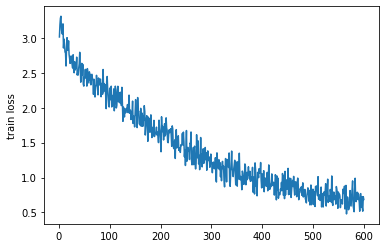

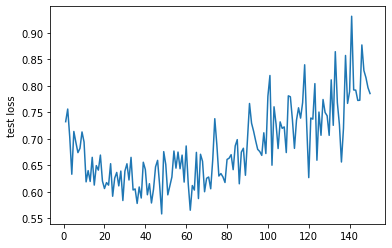

Finished Training


In [ ]:
import os
from torch import nn
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
device = torch.device( 'cuda' if torch.cuda.is_available() else 'cpu')
model = torch.load('/content/drive/MyDrive/yoga/models/downdog/YogaEvaNet_downdog1_split.pkl')
train_test2(model.to(device),50,50)

[1,   50] loss:0.773
[1,  100] loss:0.700
[1,  150] loss:0.496
[1,  200] loss:0.892
Test set: Average loss: 0.7519
[2,   50] loss:0.476
[2,  100] loss:0.829
[2,  150] loss:0.558
[2,  200] loss:0.655
Test set: Average loss: 0.8109
[3,   50] loss:0.870
[3,  100] loss:0.617
[3,  150] loss:0.697
[3,  200] loss:0.474
Test set: Average loss: 0.8253
[4,   50] loss:0.801
[4,  100] loss:0.529
[4,  150] loss:0.674
[4,  200] loss:0.777
Test set: Average loss: 0.8041
[5,   50] loss:0.685
[5,  100] loss:0.491
[5,  150] loss:0.478
[5,  200] loss:0.820
Test set: Average loss: 0.8186
[6,   50] loss:0.798
[6,  100] loss:0.608
[6,  150] loss:0.617
[6,  200] loss:0.682
Test set: Average loss: 0.8605
[7,   50] loss:0.609
[7,  100] loss:0.426
[7,  150] loss:0.574
[7,  200] loss:0.543
Test set: Average loss: 0.7557
[8,   50] loss:0.821
[8,  100] loss:0.606
[8,  150] loss:0.572
[8,  200] loss:0.655
Test set: Average loss: 0.9703
[9,   50] loss:0.779
[9,  100] loss:0.840
[9,  150] loss:0.647
[9,  200] loss:0.

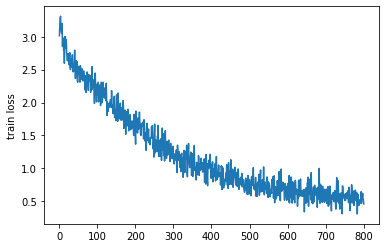

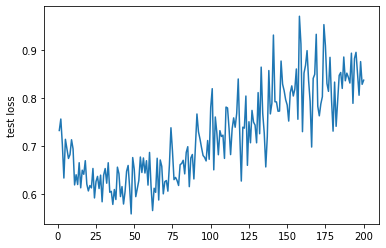

Finished Training


In [ ]:
import os
from torch import nn
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
device = torch.device( 'cuda' if torch.cuda.is_available() else 'cpu')
model = torch.load('/content/drive/MyDrive/yoga/models/downdog/YogaEvaNet_downdog1_split.pkl')
train_test2(model.to(device),50,50)

[1,   50] loss:0.580
[1,  100] loss:0.599
[1,  150] loss:0.503
[1,  200] loss:0.690
Test set: Average loss: 0.9327
[2,   50] loss:0.626
[2,  100] loss:0.345
[2,  150] loss:0.574
[2,  200] loss:0.348
Test set: Average loss: 0.8377
[3,   50] loss:0.407
[3,  100] loss:0.445
[3,  150] loss:0.649
[3,  200] loss:0.517
Test set: Average loss: 0.8632
[4,   50] loss:0.441
[4,  100] loss:0.477
[4,  150] loss:0.463
[4,  200] loss:0.591
Test set: Average loss: 0.8430
[5,   50] loss:0.607
[5,  100] loss:0.508
[5,  150] loss:0.590
[5,  200] loss:0.440
Test set: Average loss: 0.8862
[6,   50] loss:0.369
[6,  100] loss:0.388
[6,  150] loss:0.660
[6,  200] loss:0.572
Test set: Average loss: 0.9574
[7,   50] loss:0.567
[7,  100] loss:0.686
[7,  150] loss:0.794
[7,  200] loss:0.400
Test set: Average loss: 0.9149
[8,   50] loss:0.388
[8,  100] loss:0.518
[8,  150] loss:0.654
[8,  200] loss:0.728
Test set: Average loss: 0.8198
[9,   50] loss:0.356
[9,  100] loss:0.664
[9,  150] loss:0.612
[9,  200] loss:0.

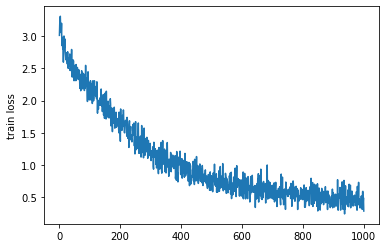

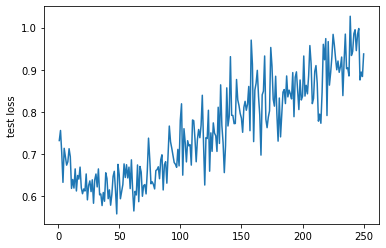

Finished Training


In [6]:
import os
from torch import nn
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
device = torch.device( 'cuda' if torch.cuda.is_available() else 'cpu')
model = torch.load('/content/drive/MyDrive/yoga/models/downdog/YogaEvaNet_downdog1_split.pkl')
train_test2(model.to(device),50,50)

In [ ]:
#训练150个epoch后的测试结果
device = torch.device( 'cuda' if torch.cuda.is_available() else 'cpu')
model = torch.load('/content/drive/MyDrive/yoga/models/downdog/YogaEvaNet_downdog1_split.pkl')
model.to(device)
print("测试精度如下：")
test(model)

测试精度如下：
测试集精度为：75%
测试集中不标准动作图片的预测精度为：64%
测试集中标准动作图片的预测精度为：84%
混淆矩阵为：
col_0  0.0  1.0
row_0          
0.0     34   19
1.0     10   56


In [ ]:
#训练200个epoch后的测试结果
device = torch.device( 'cuda' if torch.cuda.is_available() else 'cpu')
model = torch.load('/content/drive/MyDrive/yoga/models/downdog/YogaEvaNet_downdog1_split.pkl')
model.to(device)
print("测试精度如下：")
test(model)

测试精度如下：
测试集精度为：78%
测试集中不标准动作图片的预测精度为：69%
测试集中标准动作图片的预测精度为：86%
混淆矩阵为：
col_0  0.0  1.0
row_0          
0.0     37   16
1.0      9   57


In [14]:
#训练250个epoch后的测试结果
device = torch.device( 'cuda' if torch.cuda.is_available() else 'cpu')
model = torch.load('/content/drive/MyDrive/yoga/models/downdog/YogaEvaNet_downdog1_split.pkl')
model.to(device)
print("测试精度如下：")
test(model)

测试精度如下：
测试集精度为：76%
测试集中不标准动作图片的预测精度为：66%
测试集中标准动作图片的预测精度为：84%
混淆矩阵为：
col_0  0.0  1.0
row_0          
0.0     35   18
1.0     10   56
